# Belka wspornikowa: identyfikacja modułu Younga z pomiaru ugięcia

Wspornik jak w poprzednim notatniku, ale **$E$ nieznane**. Znamy zmierzone (zaszumione) ugięcie w `N_MEAS` punktach. Przy `N_MEAS = 1` czujnik stoi na końcu swobodnym $x=0$.

<p align="center"><img src="../../figures/cantilever_geometry.png" width="600"></p>

<div align="center">

| $p$ | $b$ | $c$ | $l$ | $E$ |
|---|---|---|---|---|
| 0,4 kN/cm | 20 cm | 25 cm | 200 cm | **nieznane** |

</div>

Szukamy $E$ razem z $\mathsf v(x)$, startując od pierwszego przybliżenia $E_0$.

### Zadanie odwrotne

$E$ staje się parametrem uczonym razem z wagami sieci. Do kosztu dochodzi składnik z pomiarów:

$$L = L_{\mathrm{PDE}} + L_{M(0)} + L_{T(0)} + L_{\varphi(l)} + L_{\mathsf v(l)} + \underbrace{\frac1N\sum_{i=1}^{N}\big(\mathsf v(x_i)-\mathsf v_i\big)^2}_{L_{\mathrm{pom}}}$$

Równanie i warunki brzegowe dają kształt linii ugięcia, pomiar daje jej amplitudę, czyli $EJ_z$.

### Normalizacja (propozycja: jedna skala ugięcia)

Ugięcie odniesienia $\mathsf v_0$ liczymy z pierwszego przybliżenia $E_0$. To zwykła długość w cm, znana przed treningiem:

$$\mathsf v_0=\frac{p\,l^4}{E_0J_z},\qquad x=l\,\xi,\qquad \mathsf v=\mathsf v_0\,\hat v$$

Równanie w zmiennych bezwymiarowych:

$$\dfrac{d^4\hat v}{d\xi^4}+\theta=0,\qquad \theta=\frac{E_0}{E},\qquad \theta_{\mathrm{start}}=1$$

Pomiary dzielimy przez tę samą skalę:

$$\hat v_i=\frac{\mathsf v_i}{\mathsf v_0}$$

Rozwiązanie dokładne: $\hat v(\xi)=-\dfrac{\theta}{24}\left(\xi^4-4\xi+3\right)$, czyli na końcu swobodnym $\hat v(0)=-\theta/8$.

Powrót do wielkości fizycznych:

$$E=\frac{E_0}{\theta},\qquad \mathsf v(x)=\mathsf v_0\,\hat v(\xi),\qquad M_z(x)=-\frac{p\,l^2}{\theta}\,\dfrac{d^2\hat v}{d\xi^2},\qquad T_y(x)=-\frac{p\,l}{\theta}\,\dfrac{d^3\hat v}{d\xi^3}$$

In [2]:
import os
os.environ["DDE_BACKEND"] = "pytorch"   # DeepXDE liczy w PyTorch

import numpy as np
import matplotlib.pyplot as plt
import deepxde as dde
import torch
SEED = 0
dde.config.set_random_seed(SEED)

# dane [kN, cm]
p = 0.4      # obciążenie liniowe [kN/cm]
b = 20.0     # szerokość przekroju [cm]
c = 25.0     # połowa wysokości przekroju [cm]
l = 200.0    # długość wspornika [cm]
J = 2 / 3 * b * c**3             # moment bezwładności [cm⁴]

E0 = 300000.0   # pierwsze przybliżenie modułu Younga [kN/cm²]

# parametry sieci i treningu
ITERATIONS = 1000   # iteracje Adama (potem L-BFGS)
LR = 0.005          # krok uczenia (Adam)
WIDTH = 50          # neurony w warstwie ukrytej (3 warstwy)
N_COL = 40          # punkty kolokacyjne
SEED = 0            # ziarno losowania: powtarzalny start sieci

LOSS_LABELS = ["PDE", "M(0)=0", "T(0)=0", "φ(l)=0", "v(l)=0", "pomiary"]

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


### Pomiary (sztuczne)

Z rozwiązania analitycznego dla $E_{\mathrm{true}}=3000$ kN/cm², z szumem 1% maksymalnego ugięcia. Sieć $E_{\mathrm{true}}$ nie widzi.

In [3]:
E_true = 3000.0   # tylko do wygenerowania pomiarów i oceny wyniku [kN/cm²]

def v_exact(x):
    return p / (16 * E_true * b * c**3) * (4 * l**3 * x - x**4 - 3 * l**4)

def M_exact(x):
    return p * x**2 / 2

def T_exact(x):
    return p * x

# punkty pomiarowe na długości belki (kolumna N × 1)
N_MEAS = 1                                # liczba punktów pomiarowych
NOISE = 0.01                               # szum: 1% maksymalnego ugięcia
if N_MEAS == 1:
    x_meas = np.array([[0.0]])             # jeden czujnik: na końcu swobodnym, x = 0
else:
    x_meas = np.linspace(0, l, N_MEAS, endpoint=False).reshape(-1, 1)
rng = np.random.default_rng(0)
v_meas = v_exact(x_meas)
v_meas = v_meas + NOISE * np.abs(v_meas).max() * rng.standard_normal(v_meas.shape)

# skala ugięcia z pierwszego przybliżenia E₀:
v0 = p * l**4 / (E0 * J)   # ugięcie odniesienia [cm]
print("v0 =", v0, "cm")

# punkty do wykresów
x = np.linspace(0, l, 500).reshape(500, 1)
xi = x / l
xi_meas = x_meas / l

def error_L2(v):
    return np.linalg.norm(v - v_exact(x)) / np.linalg.norm(v_exact(x))

v0 = 0.01024 cm


### Pochodne, warunki brzegowe, pomiary

Pomiary wchodzą przez `PointSetBC` jako punkty $\big(\xi_i,\;\hat v_i\big)$.

In [4]:
geom_xi = dde.geometry.Interval(0, 1)

# pochodne ugięcia po ξ
def dv_dxi(v, xi):
    return dde.grad.jacobian(v, xi)

def d2v_dxi2(v, xi):
    return dde.grad.jacobian(dv_dxi(v, xi), xi)

def d3v_dxi3(v, xi):
    return dde.grad.jacobian(d2v_dxi2(v, xi), xi)

def d4v_dxi4(v, xi):
    return dde.grad.jacobian(d3v_dxi3(v, xi), xi)

# brzegi
def free_end(xi, on_boundary):      # ξ = 0
    return on_boundary and np.isclose(xi[0], 0)

def clamped_end(xi, on_boundary):   # ξ = 1
    return on_boundary and xi[0] > 0

# ZMIANA: dołączamy pomiary do warunków brzegowych
bcs = [
    dde.icbc.OperatorBC(geom_xi, lambda xi, v, _: d2v_dxi2(v, xi), free_end),      # M_z(0) = 0
    dde.icbc.OperatorBC(geom_xi, lambda xi, v, _: d3v_dxi3(v, xi), free_end),      # T_y(0) = 0
    dde.icbc.OperatorBC(geom_xi, lambda xi, v, _: dv_dxi(v, xi), clamped_end),     # φ(1) = 0
    dde.icbc.DirichletBC(geom_xi, lambda xi: 0, clamped_end),                      # v(1) = 0
    dde.icbc.PointSetBC(xi_meas, v_meas / v0),                                    # pomiary: v̂(ξᵢ) = vᵢ / v0
]

### Trening: Adam, potem L-BFGS

$\theta$ trafia do optymalizatora przez `external_trainable_variables`.

In [4]:
theta = dde.Variable(1.0)   # parametr uczony: θ = E₀ / E, bezwymiarowy

def E_of_theta():
    return E0 / theta.item()

# równanie: d⁴v̂/dξ⁴ + θ = 0,   czyli d⁴v̂/dξ⁴ + E₀/E = 0
def pde(xi, v):
    return d4v_dxi4(v, xi) + theta


class EHistory(dde.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.steps, self.E = [], []

    def on_epoch_end(self):
        self.steps.append(self.model.train_state.step)
        self.E.append(E_of_theta())


dde.config.set_random_seed(SEED)

data = dde.data.PDE(geom_xi, pde, bcs, num_domain=N_COL, num_boundary=2)
net = dde.nn.FNN([1, WIDTH, WIDTH, WIDTH, 1], "tanh", "Glorot uniform")
model = dde.Model(data, net)
history = EHistory()

model.compile("adam", lr=LR, external_trainable_variables=[theta])
losshistory, _ = model.train(iterations=ITERATIONS, display_every=500, callbacks=[history])
print("E po Adamie  =", E_of_theta(), "kN/cm²")

model.compile("L-BFGS", external_trainable_variables=[theta])
losshistory, _ = model.train(display_every=500, callbacks=[history])
print("E po L-BFGS  =", E_of_theta(), "kN/cm²")

Compiling model...
'compile' took 0.595130 s

Training model...

Step      Train loss                                                      Test loss                                                       Test metric
0         [9.20e-01, 0.00e+00, 1.28e-03, 3.46e-03, 2.55e-03, 1.56e+02]    [9.20e-01, 0.00e+00, 1.28e-03, 3.46e-03, 2.55e-03, 1.56e+02]    []  


500       [3.10e-01, 3.17e+00, 1.37e+00, 1.34e+01, 1.29e+01, 1.31e+01]    [3.10e-01, 3.17e+00, 1.37e+00, 1.34e+01, 1.29e+01, 1.31e+01]    []  
1000      [2.72e-01, 3.64e+00, 7.79e-01, 1.13e+01, 1.41e+01, 1.21e+01]    [2.72e-01, 3.64e+00, 7.79e-01, 1.13e+01, 1.41e+01, 1.21e+01]    []  

Best model at step 1000:
  train loss: 4.22e+01
  test loss: 4.22e+01
  test metric: []

'train' took 9.996365 s

E po Adamie  = 65221.69934841082 kN/cm²
Compiling model...
'compile' took 0.000126 s

Training model...

Step      Train loss                                                      Test loss                                                       Test metric
1000      [2.72e-01, 3.64e+00, 7.79e-01, 1.13e+01, 1.41e+01, 1.21e+01]    [2.72e-01, 3.64e+00, 7.79e-01, 1.13e+01, 1.41e+01, 1.21e+01]    []  
1489      [8.00e-02, 4.67e-04, 1.18e-04, 8.75e-05, 7.11e-04, 3.54e-03]    [8.00e-02, 4.67e-04, 1.18e-04, 8.75e-05, 7.11e-04, 3.54e-03]    []  

Best model at step 1489:
  train loss: 8.49e-02
  test lo

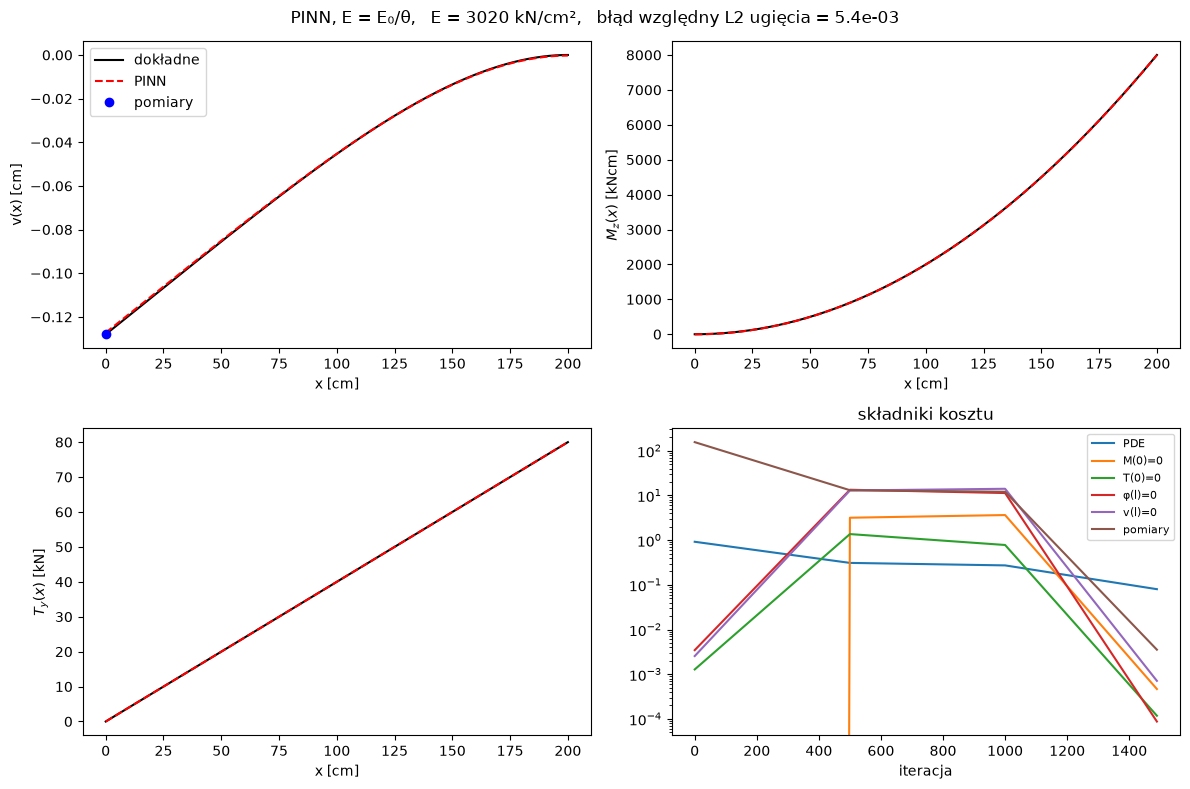

In [5]:
def plot(model, E_found, losshistory, title):
    # skalowanie na końcu: v = v0 · v̂,   v0 = p·l⁴/(E₀·J)
    v = v0 * model.predict(xi)
    # M_z = -EJ/l² · v0 · d²v̂/dξ²,   T_y = -EJ/l³ · v0 · d³v̂/dξ³
    M = model.predict(xi, operator=lambda xi, v: -E_found * J * v0 / l**2 * d2v_dxi2(v, xi))
    T = model.predict(xi, operator=lambda xi, v: -E_found * J * v0 / l**3 * d3v_dxi3(v, xi))

    fig, ax = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(title + ",   E = %.0f kN/cm²,   błąd względny L2 ugięcia = %.1e" % (E_found, error_L2(v)))

    ax[0, 0].plot(x, v_exact(x), "k-", label="dokładne")
    ax[0, 0].plot(x, v, "r--", label="PINN")
    ax[0, 0].plot(x_meas, v_meas, "bo", label="pomiary")
    ax[0, 0].set(xlabel="x [cm]", ylabel="v(x) [cm]")
    ax[0, 0].legend()

    ax[0, 1].plot(x, M_exact(x), "k-")
    ax[0, 1].plot(x, M, "r--")
    ax[0, 1].set(xlabel="x [cm]", ylabel="$M_z(x)$ [kNcm]")

    ax[1, 0].plot(x, T_exact(x), "k-")
    ax[1, 0].plot(x, T, "r--")
    ax[1, 0].set(xlabel="x [cm]", ylabel="$T_y(x)$ [kN]")

    ax[1, 1].semilogy(losshistory.steps, losshistory.loss_train, label=LOSS_LABELS)
    ax[1, 1].set(xlabel="iteracja", title="składniki kosztu")
    ax[1, 1].legend(fontsize=8)
    fig.tight_layout()
    return v


v_pinn = plot(model, E_of_theta(), losshistory, "PINN, E = E₀/θ")

E PINN = 3019.9 kN/cm²,   błąd E = 0.66%,   błąd L2 ugięcia = 5.4e-03


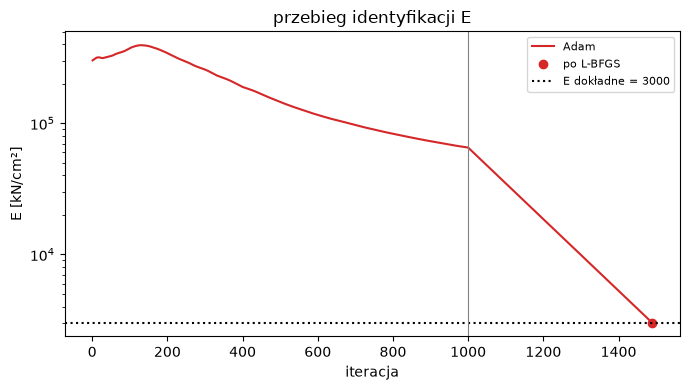

In [6]:
E_pinn = E_of_theta()

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(history.steps, history.E, "C3-", label="Adam")
ax.semilogy(history.steps[-1], history.E[-1], "C3o", label="po L-BFGS")
ax.axhline(E_true, color="k", ls=":", label="E dokładne = 3000")
ax.axvline(ITERATIONS, color="gray", lw=0.8)
ax.set(xlabel="iteracja", ylabel="E [kN/cm²]", title="przebieg identyfikacji E")
ax.legend(fontsize=8)
fig.tight_layout()

print("E PINN = %.1f kN/cm²,   błąd E = %.2f%%,   błąd L2 ugięcia = %.1e"
      % (E_pinn, 100 * abs(E_pinn - E_true) / E_true, error_L2(v_pinn)))